<a href="https://colab.research.google.com/github/Owen4GISJob/Unit_2-GIS_Processing_in_Colab/blob/main/Von_schonfeldt_Unit_2_GIS_Processing_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Groupwork: Working with Real World Data in GIS Programming**

**Mode:** Individual *or* groups of 2–3.  
**Goal:** Build a small, end-to-end **vector + raster** GIS workflow in Python, and demonstrate **QA/QC thinking** (CRS, geometry, NoData, joins, and error handling).

<br>

---

<br>

## What you will produce (deliverables):

1. A **reproducible Colab notebook** that runs top-to-bottom (after the data download step).
2. A **final map figure** showing:
   - Your **study area boundary**
   - At least **one vector layer** clipped to your study area
   - At least **one raster** clipped/masked to your study area
3. A short **QA/QC & logic report** (3–8 bullets) inside this notebook explaining:
   - What you checked, what you found, and what you fixed
   - At least one error you encountered (or anticipated) and how you handled it

#### **General Expectations**

- You should **inspect** before you process.
- You should be able to answer: “What is an *observation* in this layer? What does each row/pixel represent?”
- You must **check CRS** and **fix CRS mismatches** (reproject).
- You must handle **NoData** in rasters intentionally.
- You must show at least one **join** (attribute join or spatial join).
- Your code should be readable, commented, and include basic **try/except** where appropriate.

<br>

## Data requirements

You must use **all three**:

- **Study area boundary (vector polygon)**  
  Example: a city boundary, watershed, park boundary, county, neighborhood, etc.

- **At least one additional vector dataset** (points/lines/polygons)  
  Examples: roads, trails, parcels, census tracts, tree points, stream lines, building footprints, fire perimeters, etc.

- **At least one raster dataset**  
  Examples: DEM, land cover, NDVI, temperature, precipitation, night lights, canopy height, etc.

<br>

---

<br>

### **Possible Data Repos**

Use any public data source that provides downloadable GIS formats (GeoJSON, Shapefile, GeoPackage, GeoTIFF, etc.). Examples:

- OpenStreetMap extracts (vector)
- City / County / State open data portals (vector + raster)
- USGS / NASA / NOAA portals (raster)
- Natural Earth (vector)

**Important:** You already have a workflow for downloading from a public URL with `requests`. In the next section you will **paste that workflow** into this notebook.

### *Suggested Themes*

- Urban heat + green space
- Flood risk + elevation
- Wildfire perimeter + vegetation or burn severity
- Access to parks + population or neighborhood boundaries
- Coastal change + elevation / land cover
- Anything else that is reasonable and spatially interesting

<br>

---

<br>


## File Organization

Create a working folder structure like:

- `data_raw/` (original downloads)
- `data_processed/` (clipped/reprojected outputs)
- `figures/` (maps and plots)

In [ ]:
# --- Setup: imports and folders ---
import os
import requests
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
import matplotlib.pyplot as plt

# Optional (nice to have)
try:
    import contextily as ctx
    HAS_CONTEXTILY = True
except Exception:
    HAS_CONTEXTILY = False

# Create folders
ROOT = Path.cwd()
RAW = ROOT / "data_raw"
PROCESSED = ROOT / "data_processed"
FIGS = ROOT / "figures"

for p in [RAW, PROCESSED, FIGS]:
    p.mkdir(parents=True, exist_ok=True)

print("Folders ready:")
print("RAW:", RAW)
print("PROCESSED:", PROCESSED)
print("FIGS:", FIGS)


Folders ready:
RAW: /content/data_raw
PROCESSED: /content/data_processed
FIGS: /content/figures


# **Step 1** Data download (paste your `requests` workflow here)

In your other notebook, you already have a working pattern for:

- downloading a file from a URL with `requests`
- saving it to disk (e.g., `data_raw/`)
- unzipping if needed

<br>

**Task (you):** Paste that workflow below and download your chosen datasets.

<br>

### Checklist
- [ ] Study area boundary vector downloaded
- [ ] At least one additional vector layer downloaded
- [ ] At least one raster downloaded (GeoTIFF preferred)

<br>

### **Tip**: If you download a zipped Shapefile, remember it contains multiple files. Keep them together.


In [ ]:
#Vector: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_2_counties.zip 353 or 535 is LA
#https://stg-arcgisazurecdataprod.az.arcgis.com/exportfiles-3435-86729/Countywide_Parks_and_Open_Space__%28Public_-_Hosted2%29_-4719792574137871893.zip?sv=2025-05-05&st=2026-02-11T21%3A59%3A34Z&se=2026-02-11T23%3A04%3A34Z&sr=c&sp=r&sig=JFMBFf1Qrkp%2Bj4v8LjDcPpvYXUxho7NSNujYOT79TYc%3D
#Raster: NDVI: https://dds.cr.usgs.gov/download/eyJpZCI6OTM1NjUzMDkyLCJjb250YWN0SWQiOjI3ODM5NTA2fQ==/
#Temp: https://dds.cr.usgs.gov/download/eyJpZCI6OTM1NjU2MDU5LCJjb250YWN0SWQiOjI3ODM5NTA2fQ==

In [ ]:
file_url = "https://stg-arcgisazurecdataprod.az.arcgis.com/exportfiles-3435-86729/Countywide_Parks_and_Open_Space__%28Public_-_Hosted2%29_-3213824929624127604.zip?sv=2025-05-05&st=2026-03-04T21%3A40%3A47Z&se=2026-03-04T22%3A45%3A47Z&sr=c&sp=r&sig=nHKdL10Quev3MflCgG8mhJjBq7UgfWZz68VOeCLrPQM%3D"

r = requests.get(file_url)
with open("/content/Countywide_Parks_and_Open_Space__(Public_-_Hosted2)_-4719792574137871893", "wb") as file:
	for block in r.iter_content(chunk_size = 1024):
		if block:
			file.write(block)

!unzip "/content/Countywide_Parks_and_Open_Space__(Public_-_Hosted2)_-4719792574137871893"

Archive:  /content/Countywide_Parks_and_Open_Space__(Public_-_Hosted2)_-4719792574137871893
  inflating: Countywide_Parks_Open_Space_Local.cpg  
  inflating: Countywide_Parks_Open_Space_Local.dbf  
  inflating: Countywide_Parks_Open_Space_Local.prj  
  inflating: Countywide_Parks_Open_Space_Local.shp  
  inflating: Countywide_Parks_Open_Space_Local.shp.xml  
  inflating: Countywide_Parks_Open_Space_Local.shx  


In [ ]:
file_url = "https://stg-arcgisazurecdataprod.az.arcgis.com/exportfiles-3435-86729/Countywide_Parks_and_Open_Space__%28Public_-_Hosted2%29_-5584827434707514242.csv?sv=2025-05-05&st=2026-03-02T21%3A12%3A32Z&se=2026-03-02T22%3A17%3A32Z&sr=c&sp=r&sig=M9nOrpoKI4Sn4UcbWMLyDf%2Fpe2%2BJDVVhEDmpEIWgjTQ%3D"

r = requests.get(file_url)
with open("/content/Countywide_Parks_and_Open_Space__(Public_-_Hosted2)_-5584827434707514242", "wb") as file:
	for block in r.iter_content(chunk_size = 1024):
		if block:
			file.write(block)

In [ ]:
file_url = "https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_2_counties.zip"

r = requests.get(file_url)
with open("/content/ne_10m_admin_0_countries.zip", "wb") as file:
	for block in r.iter_content(chunk_size = 1024):
		if block:
			file.write(block)

!unzip "/content/ne_10m_admin_0_countries.zip"

Archive:  /content/ne_10m_admin_0_countries.zip
  inflating: ne_10m_admin_2_counties.README.html  
 extracting: ne_10m_admin_2_counties.VERSION.txt  
 extracting: ne_10m_admin_2_counties.cpg  
  inflating: ne_10m_admin_2_counties.dbf  
  inflating: ne_10m_admin_2_counties.prj  
  inflating: ne_10m_admin_2_counties.shp  
  inflating: ne_10m_admin_2_counties.shx  


In [ ]:
dataPath = "/content/ne_10m_admin_2_counties.shp"
countiesCal = gpd.read_file(dataPath)
LACounty = (countiesCal.loc[[353]] ) #353 is LA County
print(LACounty)

             FEATURECLA  SCALERANK  ADM2_CODE ISO_3166_2 ISO_A2  ADM0_SR  \
353  Admin-2 scale rank          0  USA-06037      US-06     US        1   

            NAME            NAME_ALT NAME_LOCAL    TYPE  ...      NAME_PT  \
353  Los Angeles  Los Angeles County       None  County  ...  Los Angeles   

          NAME_RU      NAME_SV      NAME_TR       NAME_UK  \
353  Лос-Анджелес  Los Angeles  Los Angeles  Лос-Анджелес   

                           NAME_UR      NAME_VI  NAME_ZH  NAME_ZHT  \
353  لاس اینجلس کاؤنٹی، کیلیفورنیا  Los Angeles     洛杉矶县      洛杉磯郡   

                                              geometry  
353  MULTIPOLYGON (((-118.11739 33.74361, -118.1525...  

[1 rows x 62 columns]


In [ ]:
LACounty.to_file('LACounty.shp')

<Axes: >

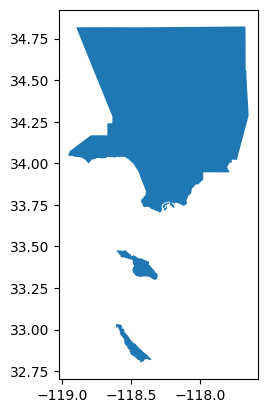

In [ ]:
LACounty.plot()

      UNIT_ID                             PARK_NAME  \
0          30                        El Barrio Park   
1          56                        El Dorado Park   
2          62                  Atlantic Avenue Park   
3          72                     El Escorpion Park   
4          78  El Marino Park/ El Marino Elementary   
...       ...                                   ...   
3015        0         Hilda S. Solis Aquatic Center   
3016        0                          Puente Hills   
3017        0                San Gabriel River Park   
3018        0                                  None   
3019        0                                  None   

                                      PARK_LBL         ACCESS_TYP  RPT_ACRES  \
0                               El Barrio Park        Open Access      2.093   
1                               El Dorado Park        Open Access      5.144   
2                         Atlantic Avenue Park        Open Access      1.960   
3                  

<Axes: >

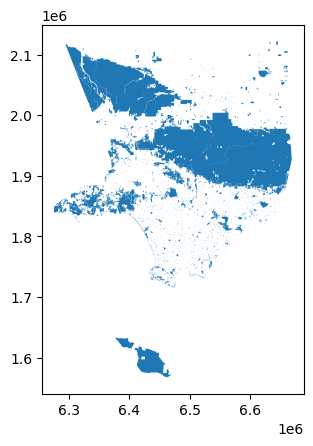

In [ ]:
dataPath = "/content/Countywide_Parks_Open_Space_Local.shp"
ParksLA = gpd.read_file(dataPath)
print(ParksLA)
ParksLA.plot()

In [ ]:
# Downloading Raster Data

# List of the band download links
# If the following links are expired, practice the EarthExplorer steps listed above.
#    - Search for Landsat 4-5 imagery on the default EarthExplorer map extent and download the first three bands (B1, B2, and B3) from the first image in the results.
file_url = "https://dds.cr.usgs.gov/download/eyJpZCI6OTQ1MDQwNjAwLCJjb250YWN0SWQiOjI3ODM5NTA2fQ=="
r = requests.get(file_url, stream=True)
with open("/content/LC09_L2SP_041036_20260218_20260219_02_T1_ST_B10.TIF", "wb") as file:
    for block in r.iter_content(chunk_size=1024):
        if block:
            file.write(block)


In [ ]:
file_url = "https://dds.cr.usgs.gov/download/eyJpZCI6OTM1NjUzMDkyLCJjb250YWN0SWQiOjI3ODM5NTA2fQ==/"
r = requests.get(file_url, stream=True)
with open("/content/US_eVSH_NDVI.2026.062-068.3KM.COMPRES.001.2026071154444.zip", "wb") as file:
    for block in r.iter_content(chunk_size=1024):
        if block:
            file.write(block)
!unzip "/content/US_eVSH_NDVI.2026.062-068.3KM.COMPRES.001.2026071154444.zip"

NameError: name 'requests' is not defined

In [ ]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

raster_file_path = '/content/US_eMAH_NDVI.2022.221-234.HKM.VI_ACQI.006.2022241144920.tif'


with rasterio.open(raster_file_path) as src:

    raster_data = src.read(1, masked=True)

    fig, ax = plt.subplots(figsize=(8, 6))

    show(src, ax=ax, title='Raster Data Plot', cmap='viridis')

    plt.show()

RasterioIOError: /content/US_eMAH_NDVI.2022.221-234.HKM.VI_ACQI.006.2022241144920.tif: No such file or directory

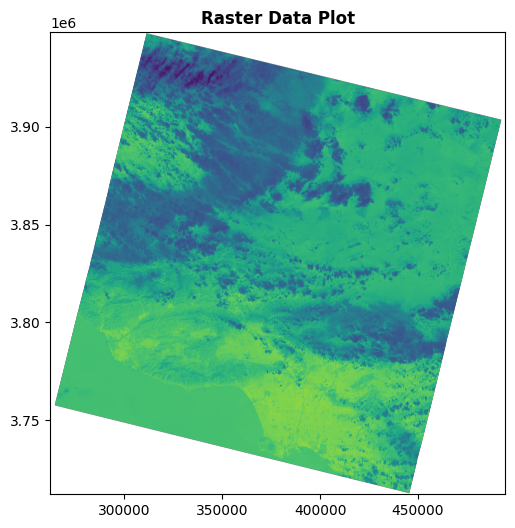

In [ ]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

raster_file_path = '/content/LC09_L2SP_041036_20260218_20260219_02_T1_ST_B10.TIF'


with rasterio.open(raster_file_path) as src:

    raster_data = src.read(1, masked=True)

    fig, ax = plt.subplots(figsize=(8, 6))

    show(src, ax=ax, title='Raster Data Plot', cmap='viridis')

    plt.show()

In [ ]:
# TODO: Paste your requests-based download workflow here.
# Save everything into RAW (data_raw/).
#
# Example variable names you should create:
# boundary_path = RAW / "my_boundary_file.geojson"  # or .shp/.gpkg
# vector_path   = RAW / "my_vector_layer.gpkg"      # or .shp/.geojson
# raster_path   = RAW / "my_raster.tif"
#
# After downloading, set these paths below.
boundary_path = RAW / "/content/LACounty.shp"
vector_path   = RAW / "/content/Countywide_Parks_Open_Space_Local.shp"      # or .shp/.geojson
raster_path   = RAW / "/content/LC09_L2SP_041036_20260218_20260219_02_T1_ST_B10.TIF"
raster_path2  = RAW / "/content/US_eMAH_NDVI.2022.221-234.HKM.VI_ACQI.006.2022241144920.tif"

print("Set boundary_path, vector_path, raster_path2,  raster_path once downloads are complete.")


Set boundary_path, vector_path, raster_path2,  raster_path once downloads are complete.


# **Step 2** Helper functions for QA/QC

These helpers keep your notebook clean and encourage consistent checks.


In [ ]:
def describe_gdf(gdf: gpd.GeoDataFrame, name="layer"):
    print(f"---]NAME]---")
    print("Rows:", len(gdf))
    print("CRS:", gdf.crs)
    print("Geometry types:", gdf.geometry.geom_type.value_counts().to_dict())
    print("Bounds (minx, miny, maxx, maxy):", gdf.total_bounds)
    print("Columns:", list(gdf.columns))
    print("Missing geometry:", gdf.geometry.isna().sum())
    if "geometry" in gdf.columns:
        invalid = (~gdf.is_valid).sum()
        print("Invalid geometries:", int(invalid))
    print()

def quickplot_gdf(gdf: gpd.GeoDataFrame, title=""):
    ax = gdf.plot(figsize=(6, 6), edgecolor="black")
    ax.set_title(title)
    ax.set_axis_off()
    plt.show()

def raster_info(src: rasterio.io.DatasetReader):
    print("---raster---")
    print("CRS:", src.crs)
    print("Shape (rows, cols):", src.height, src.width)
    print("Count (bands):", src.count)
    print("Dtype:", src.dtypes)
    print("Transform:", src.transform)
    print("NoData:", src.nodata)
    print("Bounds:", src.bounds)
    print()

def quicklook_raster(src: rasterio.io.DatasetReader, band=1, title=""):
    arr = src.read(band, masked=True)
    plt.figure(figsize=(6, 6))
    plt.imshow(arr)
    plt.title(title or f"Raster quicklook (band {band})")
    plt.axis("off")
    plt.show()


# **Step 3** Load Datasets

**Task:** Load your boundary and vector layers with GeoPandas, and open your raster with Rasterio.

<br>

**QA/QC requirements (you must document):**
- Confirm each layer loads
- Inspect columns and geometry types
- Check CRS for each layer
- Confirm the raster NoData value (and whether it “makes sense”)


---]NAME]---
Rows: 1
CRS: EPSG:4326
Geometry types: {'MultiPolygon': 1}
Bounds (minx, miny, maxx, maxy): [-118.95403654   32.80241614 -117.64741837   34.82279274]
Columns: ['FEATURECLA', 'SCALERANK', 'ADM2_CODE', 'ISO_3166_2', 'ISO_A2', 'ADM0_SR', 'NAME', 'NAME_ALT', 'NAME_LOCAL', 'TYPE', 'TYPE_EN', 'CODE_LOCAL', 'REGION', 'REGION_COD', 'ABBREV', 'AREA_SQKM', 'SAMEASCITY', 'LABELRANK', 'NAME_LEN', 'MAPCOLOR9', 'MAPCOLOR13', 'FIPS', 'SOV_A3', 'ADM0_A3', 'ADM0_LABEL', 'ADMIN', 'GEONUNIT', 'GU_A3', 'MIN_LABEL', 'MAX_LABEL', 'MIN_ZOOM', 'WIKIDATAID', 'NE_ID', 'latitude', 'longitude', 'NAME_AR', 'NAME_BN', 'NAME_DE', 'NAME_EL', 'NAME_EN', 'NAME_ES', 'NAME_FA', 'NAME_FR', 'NAME_HE', 'NAME_HI', 'NAME_HU', 'NAME_ID', 'NAME_IT', 'NAME_JA', 'NAME_KO', 'NAME_NL', 'NAME_PL', 'NAME_PT', 'NAME_RU', 'NAME_SV', 'NAME_TR', 'NAME_UK', 'NAME_UR', 'NAME_VI', 'NAME_ZH', 'NAME_ZHT', 'geometry']
Missing geometry: 0
Invalid geometries: 0

---]NAME]---
Rows: 3020
CRS: EPSG:2229
Geometry types: {'Polygon': 2434

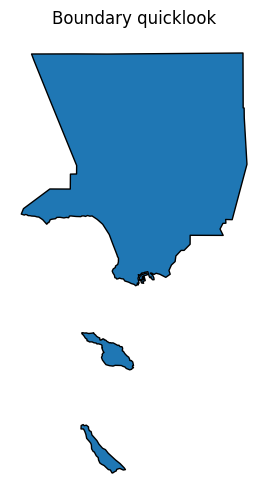

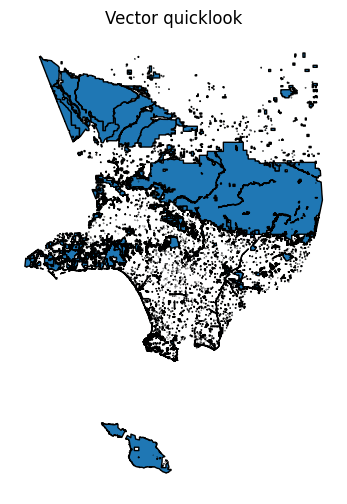

In [ ]:
# --- Load vectors ---
assert boundary_path is not None, "Set boundary_path to your boundary file path."
assert vector_path is not None, "Set vector_path to your vector file path."
assert raster_path is not None, "Set raster_path to your raster file path."

boundary = gpd.read_file(boundary_path)
layer = gpd.read_file(vector_path)

describe_gdf(boundary, "boundary")
describe_gdf(layer, "vector layer")

quickplot_gdf(boundary, "Boundary quicklook")
quickplot_gdf(layer, "Vector quicklook")


---raster---
CRS: EPSG:32611
Shape (rows, cols): 7871 7751
Count (bands): 1
Dtype: ('uint16',)
Transform: | 30.00, 0.00, 262185.00|
| 0.00,-30.00, 3948315.00|
| 0.00, 0.00, 1.00|
NoData: 0.0
Bounds: BoundingBox(left=262185.0, bottom=3712185.0, right=494715.0, top=3948315.0)



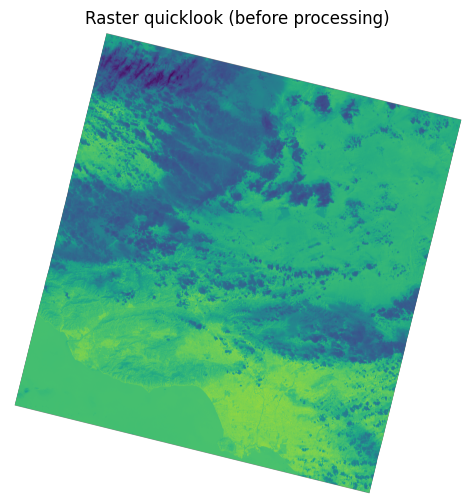

In [ ]:
# --- Open raster ---
src = rasterio.open(raster_path)
raster_info(src)
quicklook_raster(src, band=1, title="Raster quicklook (before processing)")


# **Step 4** CRS Alignment

Most GIS workflow bugs come from **CRS mismatch**.

**Task:**
1. Choose a target CRS (often the raster CRS is convenient).
2. Reproject boundary and vector layers into that CRS.
3. Re-check bounds and do a quick plot overlay to confirm alignment.

<br>

### **Tip:** Use `boundary.to_crs(target_crs)` and `layer.to_crs(target_crs)`.


---]NAME]---
Rows: 1
CRS: PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32611"]]
Geometry types: {'MultiPolygon': 1}
Bounds (minx, miny, maxx, maxy): [ 319637.07206806 3630282.07559089  440413.95849018 3854494.59878404]
Columns: ['FEATURECLA', 'SCALERANK', 'ADM2_CODE', 'ISO_3166_2', 'ISO_A2', 'ADM0_SR', 'NAME', 'NAME_ALT', 'NAME_LOCAL', 'TYPE', 'TYPE_EN', 'CODE_LOCAL', 'REGION', 'REGION_COD', 'ABBREV', 'AREA_SQKM', 'SAMEASCITY', 'LABELRANK', 'NAME_LEN

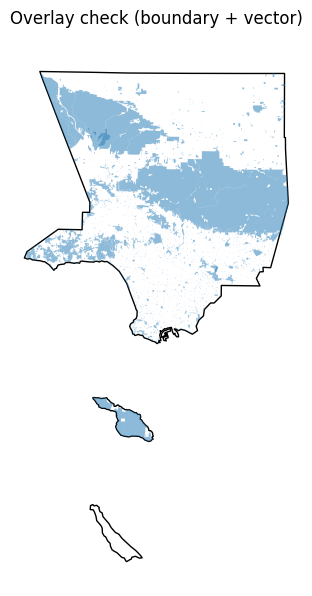

In [ ]:
# Choose target CRS (common choice: raster CRS)
target_crs = src.crs

boundary_p = boundary.to_crs(target_crs)
layer_p = layer.to_crs(target_crs)

describe_gdf(boundary_p, "boundary (projected)")
describe_gdf(layer_p, "vector layer (projected)")

# Quick overlay plot
ax = boundary_p.plot(figsize=(7, 7), facecolor="none", edgecolor="black")
layer_p.plot(ax=ax, markersize=2) if layer_p.geom_type.iloc[0] == "Point" else layer_p.plot(ax=ax, alpha=0.5)
ax.set_title("Overlay check (boundary + vector)")
ax.set_axis_off()
plt.show()


# **Step 5** Geometry QA/QC

**Task:**
- Check for invalid geometries.
- Fix them if needed (common quick fix: `buffer(0)` on polygons).
- Confirm your boundary is a single polygon (dissolve if necessary).

<br>

**Notes:**
- Invalid geometry can break clipping and spatial joins.
- A boundary may be multiparts or multiple rows (e.g., multiple admin areas).


Invalid in boundary after fix: 0
Invalid in layer after fix: 0
---]NAME]---
Rows: 1
CRS: PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32611"]]
Geometry types: {'MultiPolygon': 1}
Bounds (minx, miny, maxx, maxy): [ 319637.07206806 3630282.07559089  440413.95849018 3854494.59878404]
Columns: ['FEATURECLA', 'SCALERANK', 'ADM2_CODE', 'ISO_3166_2', 'ISO_A2', 'ADM0_SR', 'NAME', 'NAME_ALT', 'NAME_LOCAL', 'TYPE', 'TYPE_EN', 'CODE_LOCAL', 'REGION', 'REGION_CO

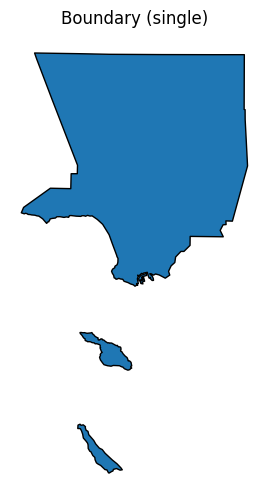

In [ ]:
# Fix invalid geometries (if any)
if (~boundary_p.is_valid).any():
    # buffer(0) can fix many polygon validity issues
    boundary_p["geometry"] = boundary_p.buffer(0)

if (~layer_p.is_valid).any():
    # Only safe-ish for polygons; for lines/points it may not apply.
    # If your layer is not polygons, consider dropping invalid or investigating.
    try:
        layer_p["geometry"] = layer_p.buffer(0)
    except Exception as e:
        print("Could not buffer-fix vector layer; investigate invalid geometries.")
        print("Error:", e)

print("Invalid in boundary after fix:", int((~boundary_p.is_valid).sum()))
print("Invalid in layer after fix:", int((~layer_p.is_valid).sum()))

# Make a single boundary polygon (optional but often helpful)
# If boundary has multiple rows, dissolve into one shape.
if len(boundary_p) > 1:
    boundary_single = boundary_p.dissolve()  # dissolves all into one row
else:
    boundary_single = boundary_p

describe_gdf(boundary_single, "boundary_single")
quickplot_gdf(boundary_single, "Boundary (single)")


# **Step 6** Clip Geometries

**Task:**
- Clip vector layer to boundary.
- Save result to `data_processed/` as GeoPackage or GeoJSON.
- Confirm the clipped layer looks right.

<br>

**QA/QC prompts (write your answers below):**
- Did the feature count change as expected?
- Did any features disappear unexpectedly? Why might that happen?


---]NAME]---
Rows: 3009
CRS: PROJCS["WGS 84 / UTM zone 11N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32611"]]
Geometry types: {'Polygon': 2422, 'MultiPolygon': 587}
Bounds (minx, miny, maxx, maxy): [ 320500.17061579 3685191.3782088   440413.95849018 3853595.08640831]
Columns: ['UNIT_ID', 'PARK_NAME', 'PARK_LBL', 'ACCESS_TYP', 'RPT_ACRES', 'GIS_ACRES', 'AGNCY_NAME', 'AGNCY_LEV', 'AGNCY_TYP', 'AGNCY_WEB', 'MNG_AGENCY', 'COGP_TYP', 'NDS_AN_TYP', 'NEEDS_ANLZ', 'TKIT_SUM', 'AMEN_RP

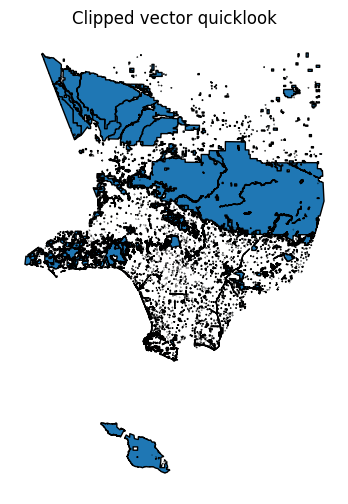

Saved: /content/data_processed/vector_clipped.gpkg


In [ ]:
# Clip vector layer
clipped_vector = gpd.clip(layer_p, boundary_single)

describe_gdf(clipped_vector, "clipped_vector")
quickplot_gdf(clipped_vector, "Clipped vector quicklook")

# Save
clipped_vector_path = PROCESSED / "vector_clipped.gpkg"
clipped_vector.to_file(clipped_vector_path, driver="GPKG")
print("Saved:", clipped_vector_path)


# **Step 7** Clip/Mask Raster

For rasters, the usual pattern is:
- convert boundary to GeoJSON-like mapping (`boundary_single.geometry`)
- `rasterio.mask.mask(...)` to clip and apply mask
- update metadata and write the new raster

<br>

**Task:**
- Clip/mask your raster to your boundary.
- Save result to `data_processed/`.
- Inspect NoData and confirm it is handled as expected.


Saved: /content/data_processed/raster_clipped.tif
---raster---
CRS: EPSG:32611
Shape (rows, cols): 4744 4026
Count (bands): 1
Dtype: ('uint16',)
Transform: | 30.00, 0.00, 319635.00|
| 0.00,-30.00, 3854505.00|
| 0.00, 0.00, 1.00|
NoData: 0.0
Bounds: BoundingBox(left=319635.0, bottom=3712185.0, right=440415.0, top=3854505.0)



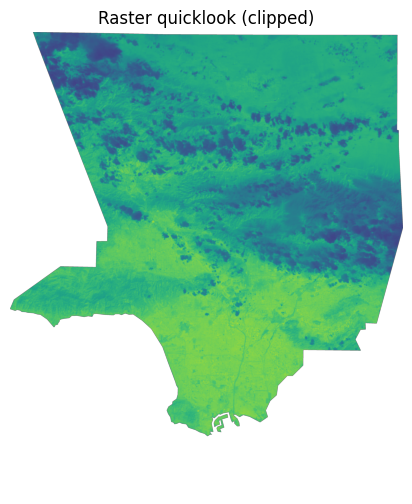

In [ ]:
from shapely.geometry import mapping

# Geometry must be in the raster CRS (we set target_crs = raster CRS earlier)
shapes = [mapping(boundary_single.geometry.iloc[0])]

out_image, out_transform = mask(src, shapes, crop=True, nodata=src.nodata, filled=True)
out_meta = src.meta.copy()

out_meta.update({
    "height": out_image.shape[1],
    "width": out_image.shape[2],
    "transform": out_transform
})

clipped_raster_path = PROCESSED / "raster_clipped.tif"
with rasterio.open(clipped_raster_path, "w", **out_meta) as dst:
    dst.write(out_image)

print("Saved:", clipped_raster_path)

# Quicklook the clipped raster
with rasterio.open(clipped_raster_path) as src_clip:
    raster_info(src_clip)
    quicklook_raster(src_clip, band=1, title="Raster quicklook (clipped)")


# **Step 8** NoData Handling and Basic Raster Stats

**Task:**
- Read the clipped raster as a masked array.
- Compute a few basic stats (min/mean/max) ignoring NoData.
- Explain what the stats mean in the context of your raster.

<br>

### **Hint:** `arr = src_clip.read(1, masked=True)`


In [ ]:
with rasterio.open(clipped_raster_path) as src_clip:
    arr = src_clip.read(1, masked=True)

# Basic stats ignoring NoData (masked values are ignored)
print("Masked cells (NoData):", int(arr.mask.sum()) if hasattr(arr, "mask") else "N/A")
print("Min:", float(arr.min()))
print("Mean:", float(arr.mean()))
print("Max:", float(arr.max()))


Masked cells (NoData): 7733823
Min: 28008.0
Mean: 39224.03634087694
Max: 47000.0


# **Step 9** Joins

You must include **at least one join**.

Choose one of these options (or propose your own):

<br>

### Option A — Attribute join
- Find a table (CSV) that shares a key with your vector layer (e.g., tract ID, neighborhood name).
- Join it to your clipped vector layer with `merge`.

<br>

### Option B — Spatial join (recommended when feasible)
- Use `gpd.sjoin` to join points to polygons (or lines to polygons) using `within` or `intersects`.
- Example: count points per polygon.

<br>

### **Task:** Implement one join and explain:
- What keys or spatial relationship you used
- What the join produced (new columns, counts, etc.)


In [ ]:
df = pd.read_csv("/content/Countywide_Parks_and_Open_Space__(Public_-_Hosted2)_-5584827434707514242")
df.columns

ParserError: Error tokenizing data. C error: Expected 1 fields in line 3, saw 4


In [ ]:
parks = gpd.read_file("/content/Countywide_Parks_Open_Space_Local.shp")
parks.columns

In [ ]:
# 2. Spatial Join (sjoin) - joins based on spatial relationship
# Options for how: 'inner', 'left', 'right'
joined = parks.merge(df, on="UNIT_ID", how="inner")

print(joined)

# **Step 10** Final Map Output

Your final figure should communicate:
- the study area boundary
- your clipped vector layer
- and a raster backdrop (clipped raster)

You may:
- plot raster with `imshow`
- plot vector with GeoPandas `.plot`
- optionally add a basemap with `contextily` (if installed)

<br>

### **Task:**
- Build a clean map figure
- Add a title, legend (if appropriate), and north arrow / scalebar if you want extra credit
- Save it to `figures/final_map.png`


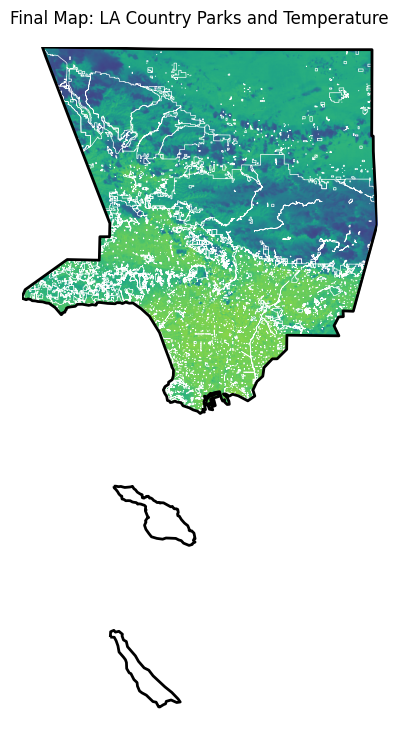

Saved: /content/figures/final_map.png


In [ ]:
# --- Load clipped raster for plotting ---
with rasterio.open(clipped_raster_path) as src_clip:
    arr = src_clip.read(1, masked=True)
    extent = (
        src_clip.bounds.left, src_clip.bounds.right,
        src_clip.bounds.bottom, src_clip.bounds.top
    )

fig, ax = plt.subplots(figsize=(9, 9))

# Raster backdrop
ax.imshow(arr, extent=extent)

# Boundary outline
boundary_single.boundary.plot(ax=ax, color="black", linewidth=2)

# Vector overlay
# Adjust styling depending on geometry type
geom_type = clipped_vector.geometry.geom_type.mode()[0]
if geom_type == "Point":
    clipped_vector.plot(ax=ax, markersize=8, zorder=2)
else:
    clipped_vector.plot(ax=ax, facecolor="none", edgecolor="white", linewidth=0.5)

ax.set_title("Final Map: LA Country Parks and Temperature")
ax.set_axis_off()

final_map_path = FIGS / "final_map.png"
plt.savefig(final_map_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", final_map_path)


# **Step 11** QA/QC & Logic Write-up

Write 3–8 bullets answering:

- What were your main workflow steps (in order)?
- What did you check about CRS and what did you do about mismatches?
- Did you find invalid geometries? If yes, what did you do?
- How did you handle NoData in your raster?
- What join did you perform, and what did you learn from it?
- One error you encountered (or anticipated) and how you handled it (or how you would handle it)

> Replace the bullets below with your own.


The main work flow was: Downloading data, Processing data, displaying/

reprojecting data, Overlaying data, then final projection/map production.

We checked for invalid geometries but there were none, if there were we would have used buffer(0) to fix it.

We used the boundry.to_crs(target_crs) and layer.to(target_crs) to reproject the vector layers with the crs.

We handed no data by masking it so the calculations using src_clip with mask = true.

We opened the csv and shp and did an attribute join. And learned nothing the csv we use is the same as the shp file but it did merge.

The error we encounted was that our boundry layer was for the entire united states, but we just wanted LA country. So we had to find the row for LA country and then turn that one row into a shp file. Which we then used for the rest of the note book.






